# Experimental ACF data and model simulations


In [1]:
import sys
from pathlib import Path

working_path = Path.cwd().resolve()
src_dir = next(path / 'src' for path in (working_path, *working_path.parents) if (path / 'src').is_dir())
sys.path.extend([str(src_dir), str(src_dir / 'pipelines')])
main_dir = src_dir.parent
from imports import * 
figure_7_dir = main_dir / 'notebooks' / 'Figure_7'
figures_folder = figure_7_dir / 'figures'
raw_data_folder = figure_7_dir / 'raw_data'
figures_folder.mkdir(parents=True, exist_ok=True)
raw_data_folder.mkdir(parents=True, exist_ok=True)
from microlive import microscopy as mi

In [2]:
from tasep_models import *
from numba import njit
import hashlib
import random

REPRODUCIBLE_RANDOM_SEED = 42
REPRODUCIBLE_N_JOBS = -1

@njit
def numba_seed(seed):
    np.random.seed(seed)

def stable_seed(*parts):
    key = '|'.join(str(part) for part in parts).encode('utf-8')
    return int.from_bytes(hashlib.blake2b(key, digest_size=4).digest(), 'little')

def seed_all_rngs(seed):
    seed = int(seed) % (2**32 - 1)
    random.seed(seed)
    np.random.seed(seed)
    numba_seed(seed)
    return seed

def _build_tasep_rate_vector(ki, ke, gene_length, pause_location=None, pause_elongation_rate=None):
    if isinstance(ke, (int, float)):
        k_elongation = np.full(gene_length - 2, ke, dtype=np.float64)
    else:
        k_elongation = np.asarray(ke, dtype=np.float64)
    k_termination = k_elongation[-1]
    k_full = np.concatenate(([ki], k_elongation, [k_termination])).astype(np.float64)
    if pause_location is not None and pause_elongation_rate is not None:
        if 0 <= pause_location < gene_length:
            k_full[pause_location] = pause_elongation_rate
        else:
            raise ValueError('pause_location must be within the range of gene_length.')
    return k_full

def _run_seeded_fast_tasep(args):
    seed, tasep_args = args
    seed_all_rngs(seed)
    return TASEP_SSA(*tasep_args)

def simulate_TASEP_SSA_seeded_fast(ki, ke, gene_length, t_max, time_interval_in_seconds=1,
                                   number_repetitions=1, first_probe_position_vector=None,
                                   timePerturbationApplication=0, evaluatingInhibitor=0,
                                   evaluatingFRAP=0, n_jobs=-1, burnin_time=0,
                                   inhibitor_effectiveness=0, constant_elongation_rate=None,
                                   pause_location=None, pause_elongation_rate=None,
                                   fast_output=True, batch_size='auto',
                                   random_seed=REPRODUCIBLE_RANDOM_SEED,
                                   seed_context='tasep'):
    if not fast_output:
        raise ValueError('simulate_TASEP_SSA_seeded_fast supports fast_output=True only.')
    if burnin_time > 0:
        timePerturbationApplication = (timePerturbationApplication or 0) + burnin_time
        t_max += burnin_time
    t_array = np.arange(0, t_max, time_interval_in_seconds, dtype=np.float64)
    k_full = _build_tasep_rate_vector(ki, ke, gene_length, pause_location, pause_elongation_rate)
    if first_probe_position_vector is None:
        first_probe_position_vector = np.empty(0, dtype=np.float64)
    else:
        first_probe_position_vector = np.asarray(first_probe_position_vector, dtype=np.float64)
    constant_rate = constant_elongation_rate if constant_elongation_rate is not None else -1.0
    tasep_args = (k_full, t_array, timePerturbationApplication, int(evaluatingInhibitor),
                  int(evaluatingFRAP), inhibitor_effectiveness, constant_rate,
                  True, first_probe_position_vector)
    args_list = [
        (stable_seed(random_seed, seed_context, rep), tasep_args)
        for rep in range(number_repetitions)
    ]
    list_first_signal = Parallel(n_jobs=n_jobs, batch_size=batch_size)(
        delayed(_run_seeded_fast_tasep)(args) for args in args_list
    )
    matrix_intensity_first_signal_RT = np.asarray(list_first_signal)
    if burnin_time > 0:
        idx_burnin = int(burnin_time / time_interval_in_seconds)
        matrix_intensity_first_signal_RT = matrix_intensity_first_signal_RT[:, idx_burnin:]
    return (None, None, matrix_intensity_first_signal_RT, None)

In [3]:
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': 'black',
    'axes.linewidth': 1.5,
    'font.family': 'sans-serif',
    'font.sans-serif': 'Arial',
    'axes.labelsize': 16,
    'axes.titlesize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'axes.labelcolor': 'black',
    'text.color': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'axes.edgecolor': 'black',
})


## Data locations


In [4]:
results_folder = main_dir / 'optimization' / 'results_ACF'
results_ACF_plots = figures_folder


## ACF parameters


In [5]:
step_size_in_sec = 5
start_lag = 0
downsample = False
downsampling_factor = 2
y_axes_min_max_list_values =  [-0.02, 0.1]
x_axes_min_max_list_values = [-0.5, 24.5]
MAD_THRESHOLD_FACTOR = 4

multi_tau=False
multi_tau_raw_points = 60
multi_tau_bins_per_stage = 16

# Model Parameters

In [6]:
number_repetitions = 200
burnin_time = 2000
t_max = 400*5
step_size_in_sec = 5
time_array = np.arange(0, t_max, step_size_in_sec)

In [7]:
def extract_params(filename):
    df = pd.read_csv(results_folder / filename)
    ki_value = df[df['parameter'] == 'ki']['value'].iloc[0]
    ke_value = df[df['parameter'] == 'ke']['value'].iloc[0]
    return float(ke_value), float(ki_value)

ke_utag, ki_utag = extract_params('optimized_params_utag.csv')
ke_utag_c_free, ki_utag_c_free = extract_params('optimized_params_utag_c_free.csv')
ke_suntag, ki_suntag = extract_params('optimized_params_suntag.csv')
ke_alfatag, ki_alfatag = extract_params('optimized_params_alfatag.csv')
param_fit_utag = [ke_utag, ki_utag, 'utag'] # ke, ki, utag
param_fit_utag_c_free = [ke_utag_c_free, ki_utag_c_free, 'utag_c_free'] # ke, ki, utag_c_free
param_fit_suntag = [ke_suntag, ki_suntag, 'suntag'] # ke, ki, suntag
param_fit_alfatag = [ke_alfatag, ki_alfatag, 'alfatag'] # ke, ki, alfatag
list_param_fit = [param_fit_utag, param_fit_utag_c_free, param_fit_suntag, param_fit_alfatag]


## Experimental datasets


In [8]:
def dataset_selection(dataset,downsample=False):
    if downsample:
        downsample_str = '_downsampled'
    else:
        downsample_str = ''
    
    if dataset == 'utag':
        plot_name = 'utag' + downsample_str
        folder_with_files = results_folder.joinpath('df_ACF_utag'+downsample_str+'.csv')
        tag_sequence = tag_dict['U']
        dna_file_path = main_dir.joinpath( 'gene_sequences','utag_project','pNZ208(pUB-24xUTagFullLength-KDM5B-MS2).dna' )
    
    elif dataset == 'utag_c_free':
        plot_name = 'utag_c_free' + downsample_str
        folder_with_files = results_folder.joinpath('df_ACF_utag_c_free'+downsample_str+'.csv')
        tag_sequence = tag_dict['U']
        dna_file_path = main_dir.joinpath( 'gene_sequences','utag_project','pNZ208(pUB-24xUTagFullLength-KDM5B-MS2).dna' )
    
    elif dataset == 'suntag':
        folder_with_files = results_folder.joinpath('df_ACF_suntag'+downsample_str+'.csv')
        plot_name = 'suntag' + downsample_str
        tag_sequence = tag_dict['SUN']
        dna_file_path = main_dir.joinpath( 'gene_sequences','utag_project','pNZ266(pUB-24xGCN4-KDM5B-MS2).dna' )
    elif dataset == 'alfatag':
        plot_name = 'alfatag' + downsample_str
        folder_with_files = results_folder.joinpath('df_ACF_alfatag'+downsample_str+'.csv')
        tag_sequence = tag_dict['ALFA']
        dna_file_path = main_dir.joinpath( 'gene_sequences','utag_project','pNZ267 (pUB-24xALFAtag-KDM5B-MS2).dna' )
    
    protein, rna, dna, indexes_tags, _, seq_record, graphic_features  = read_sequence(seq=dna_file_path, min_protein_length=50,TAG=[tag_sequence])
    gene_length = len(protein)+1 # adding 1 to account for the stop codon
    tag_positions_first_probe_vector = indexes_tags[0]
    print('dataset: ', dataset)
    print('tag_positions_first_probe_vector', tag_positions_first_probe_vector)
    print('tag_sequence_length', len(tag_positions_first_probe_vector))
    first_probe_position_vector = create_probe_vector(tag_positions_first_probe_vector, gene_length)
    dataframe_ACF = pd.read_csv(folder_with_files)
    data_mean_correlation = dataframe_ACF['mean_correlation'].values
    data_std_correlation = dataframe_ACF['std_correlation'].values
    data_lags = dataframe_ACF['lags'].values
    return data_mean_correlation,data_std_correlation,data_lags, plot_name, rna, first_probe_position_vector, gene_length


In [9]:
def plot_correlation_comparison(mean_correlation, std_correlation, lags,
                                mean_correlation_ssa=None, std_correlation_ssa=None, lags_ssa=None,  
                                plot_name='temp', start_lag=0, y_axes_min_max_list_values=None,
                                x_axes_min_max_list_values=None, show_legend=True, ke=None, ki=None,
                                color_sim='dimgray', color_exp='orangered'):



    fig, ax = plt.subplots(figsize=(6, 2.5), facecolor='white')

    
    lags = lags / 60
    if lags_ssa is not None:
        lags_ssa = lags_ssa / 60

    marker_size = 5

    maxlag = len(lags)
    maxlag_ssa = len(lags_ssa) if lags_ssa is not None else 0

    legend_label_exp = 'Experimental'
    legend_label_sim = 'Model fit'
    ax.plot(lags[start_lag:maxlag], mean_correlation[start_lag:maxlag],
            'o-', color=color_exp, linewidth=1, label=legend_label_exp, markersize=marker_size)
    ax.fill_between(lags[start_lag:maxlag],
                    mean_correlation[start_lag:maxlag] - std_correlation[start_lag:maxlag],
                    mean_correlation[start_lag:maxlag] + std_correlation[start_lag:maxlag],
                    color=color_exp, alpha=0.1)

    if mean_correlation_ssa is not None:
        ax.plot(lags_ssa[start_lag:maxlag_ssa], mean_correlation_ssa[start_lag:maxlag_ssa],
                '-', color=color_sim, linewidth=4, label=legend_label_sim)
        ax.fill_between(lags_ssa[start_lag:maxlag_ssa],
                        mean_correlation_ssa[start_lag:maxlag_ssa] - std_correlation_ssa[start_lag:maxlag_ssa],
                        mean_correlation_ssa[start_lag:maxlag_ssa] + std_correlation_ssa[start_lag:maxlag_ssa],
                        color=color_sim, alpha=0.1)

    if show_legend:
        ax.legend(loc='upper right', fontsize=12, frameon=False)

    if x_axes_min_max_list_values is not None:
        ax.set_xlim(x_axes_min_max_list_values[0], x_axes_min_max_list_values[1])

    if y_axes_min_max_list_values is not None:
        ax.set_ylim(y_axes_min_max_list_values[0], y_axes_min_max_list_values[1])

    ax.set_xlabel(r'$\tau (min)$', fontsize=18)
    ax.set_ylabel(r'$G(\tau)$', fontsize=18)
    ax.tick_params(axis='both', which='major', labelsize=16)

    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.5)

    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

    plt.tight_layout()
    plt.savefig(results_ACF_plots.joinpath(plot_name+'.png'), dpi=600)
    plt.savefig(results_ACF_plots.joinpath(plot_name+'.svg'), dpi=600, metadata={'Date': None})

    plt.show()

In [10]:
def deterministic_model_bootstrap(correlation_model, correlations_array, lags, number_timepoints,
                                  step_size_in_sec, plot_name, bootstrap_iterations=1000):
    rng = np.random.default_rng(stable_seed(REPRODUCIBLE_RANDOM_SEED, plot_name, 'acf_bootstrap'))
    number_trajectories = correlations_array.shape[0]
    lag_steps = np.rint(lags / step_size_in_sec).astype(int)
    overlap_per_trajectory = np.maximum(number_timepoints - lag_steps, 0)
    lag_weights = np.sum(np.isfinite(correlations_array), axis=0) * overlap_per_trajectory
    bootstrap_means = np.full((bootstrap_iterations, correlations_array.shape[1]), np.nan, dtype=np.float64)
    for bootstrap_index in range(bootstrap_iterations):
        sampled_indices = rng.choice(number_trajectories, size=number_trajectories, replace=True)
        bootstrap_mean = np.nanmean(correlations_array[sampled_indices, :], axis=0)
        baseline = correlation_model._estimate_baseline(
            bootstrap_mean,
            lags,
            weights=lag_weights,
            symmetric=False,
            lag_range=(0, correlation_model.max_lag * step_size_in_sec),
        )
        bootstrap_means[bootstrap_index] = bootstrap_mean - baseline
    bootstrap_error = np.nanstd(bootstrap_means, axis=0)
    bootstrap_error[0] = 0.0
    return bootstrap_error

def run_simulation(global_elongation_rate,ki, rna, first_probe_position_vector,burnin_time, gene_length, t_max, step_size_in_sec, number_repetitions, MAD_THRESHOLD_FACTOR,plot_name,save_parameters=False, downsample = False,downsampling_factor = 2, use_minutes_for_lags=False):
    ke = calculate_codon_elongation_rates(rna, global_elongation_rate=global_elongation_rate)
    ssa_array = simulate_TASEP_SSA_seeded_fast(
                                ki, ke, gene_length, t_max,
                                time_interval_in_seconds=step_size_in_sec,
                                number_repetitions=number_repetitions,
                                first_probe_position_vector=first_probe_position_vector,
                                burnin_time=burnin_time,
                                constant_elongation_rate=global_elongation_rate,
                                fast_output=True,
                                n_jobs=REPRODUCIBLE_N_JOBS,
                                random_seed=REPRODUCIBLE_RANDOM_SEED,
                                seed_context=f'{plot_name}|acf_ssa',
                                )[2]
    correlation_model = mi.Correlation(primary_data=ssa_array,
                                       max_lag=None,
                                       nan_handling='forward_fill',
                                       shift_data=True,
                                       return_full=False,
                                       time_interval_between_frames_in_seconds=step_size_in_sec,
                                       use_bootstrap=False,
                                       show_plot=False,
                                       start_lag=0,
                                       fit_type='linear',
                                       de_correlation_threshold=0.01,
                                       correct_baseline=True,
                                       use_linear_projection_for_lag_0=True,
                                       save_plots=False,
                                       use_global_mean=False,
                                       remove_outliers=True,
                                       MAD_THRESHOLD_FACTOR=MAD_THRESHOLD_FACTOR,
                                       plot_individual_trajectories=False,
                                       y_axes_min_max_list_values=None,
                                       x_axes_min_max_list_values=None,
                                       multi_tau=multi_tau,
                                       multi_tau_raw_points=multi_tau_raw_points,
                                       multi_tau_bins_per_stage=multi_tau_bins_per_stage,
                                       plot_title=None)
    mean_correlation_ssa, _, lags_ssa, correlations_array, _ = correlation_model.run()
    std_correlation_ssa = deterministic_model_bootstrap(
        correlation_model, correlations_array, lags_ssa, ssa_array.shape[1],
        step_size_in_sec, plot_name, bootstrap_iterations=1000,
    )
    if downsample:
        mean_correlation_ssa = mean_correlation_ssa[::downsampling_factor]
        std_correlation_ssa = std_correlation_ssa[::downsampling_factor]
        lags_ssa = lags_ssa[::downsampling_factor]
    return mean_correlation_ssa, std_correlation_ssa, lags_ssa

dataset  utag 

dataset:  utag
tag_positions_first_probe_vector [8, 24, 40, 56, 72, 88, 110, 126, 142, 158, 174, 190, 212, 228, 244, 260, 276, 292, 314, 330, 346, 362, 378, 394]
tag_sequence_length 24
ki_calculated 0.0312658227848101
ke_calculated 3.113924050632911
-----------------------------------------------------



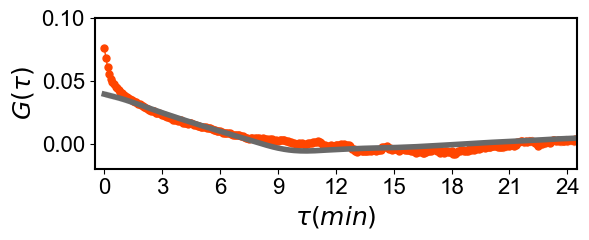

dataset  utag_c_free 

dataset:  utag_c_free
tag_positions_first_probe_vector [8, 24, 40, 56, 72, 88, 110, 126, 142, 158, 174, 190, 212, 228, 244, 260, 276, 292, 314, 330, 346, 362, 378, 394]
tag_sequence_length 24
ki_calculated 0.0631645569620253
ke_calculated 5.291139240506329
-----------------------------------------------------



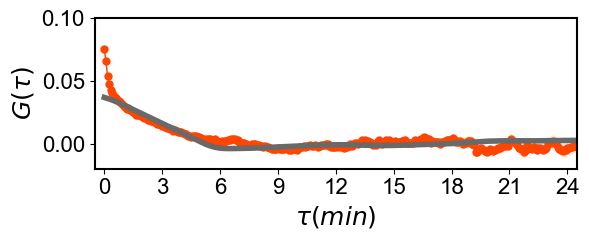

dataset  suntag 

dataset:  suntag
tag_positions_first_probe_vector [1, 25, 49, 73, 97, 121, 145, 169, 193, 217, 241, 265, 289, 313, 337, 361, 385, 409, 433, 457, 481, 505, 529, 553]
tag_sequence_length 24
ki_calculated 0.0339240506329113
ke_calculated 4.329113924050633
-----------------------------------------------------



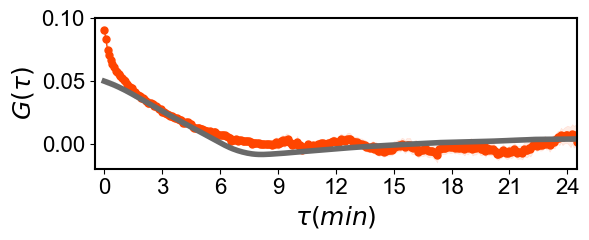

dataset  alfatag 

dataset:  alfatag
tag_positions_first_probe_vector [8, 26, 44, 62, 80, 98, 122, 140, 158, 176, 194, 212, 236, 254, 272, 290, 308, 326, 350, 368, 386, 404, 422, 440]
tag_sequence_length 24
ki_calculated 0.0427848101265822
ke_calculated 4.8354430379746836
-----------------------------------------------------



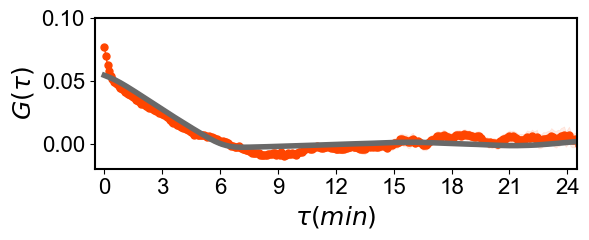

In [11]:
color_sim = 'dimgray'
def read_experimental_trajectory_count(dataset):
    report_path = results_folder / f'report_cells_trajectories_ACF_{dataset}.txt'
    if not report_path.is_file():
        raise FileNotFoundError(f'Missing ACF trajectory report: {report_path}')
    prefix = 'Number of trajectories after filtering based on quality:'
    matching_lines = [line for line in report_path.read_text().splitlines() if line.startswith(prefix)]
    if len(matching_lines) != 1:
        raise ValueError(f'Expected one trajectory-count line in {report_path}')
    return int(matching_lines[0].split(':', 1)[1].strip())

color_exp = 'orangered'
acf_publication_info = {
    'utag': {
        'figure_stem': 'Figure_7F_UTag_ACF',
        'csv_name': 'Figure_7F_UTag_ACF_curves.csv',
    },
    'utag_c_free': {
        'figure_stem': 'Figure_7G_UTag_DeltaCys_ACF',
        'csv_name': 'Figure_7G_UTag_DeltaCys_ACF_curves.csv',
    },
    'suntag': {
        'figure_stem': 'Figure_7H_SunTag_ACF',
        'csv_name': 'Figure_7H_SunTag_ACF_curves.csv',
    },
    'alfatag': {
        'figure_stem': 'Figure_7I_ALFA_tag_ACF',
        'csv_name': 'Figure_7I_ALFA_tag_ACF_curves.csv',
    },
}
visible_lags_seconds = np.arange(0, 24.5 * 60 + step_size_in_sec, step_size_in_sec)
seed_all_rngs(REPRODUCIBLE_RANDOM_SEED)

for i, param_fit in enumerate(list_param_fit):
    print('dataset ', param_fit[2] , '\n')
    data_mean_correlation,data_std_correlation,data_lags, plot_name, rna, first_probe_position_vector, gene_length = dataset_selection (param_fit[2],downsample) #suntag 
    ki_calculated = param_fit[1] #1/(param_fit[1]*param_fit[0])
    print('ki_calculated', ki_calculated)
    ke_calculated = param_fit[0] #gene_length/(param_fit[0])
    print('ke_calculated', ke_calculated)
    print('-----------------------------------------------------\n')
    ki = ki_calculated
    global_elongation_rate = ke_calculated
    mean_correlation_ssa, std_correlation_ssa, lags_ssa = run_simulation(global_elongation_rate,ki, rna, first_probe_position_vector, burnin_time, gene_length, t_max, step_size_in_sec, number_repetitions, MAD_THRESHOLD_FACTOR,plot_name,save_parameters=True,downsample = downsample,downsampling_factor =downsampling_factor)
    publication_info = acf_publication_info[plot_name]
    n_experimental_trajectories = read_experimental_trajectory_count(plot_name)
    visible_count = len(visible_lags_seconds)
    if not np.array_equal(data_lags[:visible_count], visible_lags_seconds):
        raise ValueError(f'Experimental lag grid does not match the approved Figure 7 range for {plot_name}.')
    if not np.array_equal(lags_ssa[:visible_count], visible_lags_seconds):
        raise ValueError(f'Model lag grid does not match the approved Figure 7 range for {plot_name}.')
    source_data_dataframe = pd.DataFrame({
        'lag_time_min': visible_lags_seconds / 60,
        'mean_experimental_autocorrelation': data_mean_correlation[:visible_count],
        'bootstrap_se_experimental_autocorrelation': data_std_correlation[:visible_count],
        'n_experimental_trajectories': n_experimental_trajectories,
        'mean_model_autocorrelation': mean_correlation_ssa[:visible_count],
        'bootstrap_se_model_autocorrelation': std_correlation_ssa[:visible_count],
        'n_model_repetitions': number_repetitions,
    })
    source_data_dataframe.to_csv(raw_data_folder / publication_info['csv_name'], index=False)
    # Plotting uses the complete arrays; the CSV contains only the visible 0-24.5 minute range.
    plot_correlation_comparison(data_mean_correlation, data_std_correlation, data_lags,mean_correlation_ssa, std_correlation_ssa, lags_ssa, plot_name=publication_info['figure_stem'], start_lag=start_lag, y_axes_min_max_list_values = y_axes_min_max_list_values,x_axes_min_max_list_values=x_axes_min_max_list_values,show_legend = False, ke=global_elongation_rate, ki=ki,color_sim=color_sim,color_exp=color_exp)
